# Experiment Report Dashboard

This notebook reads saved experiment outputs and compares how each model behaved across experiments. It is designed to work with whatever model names appear in the saved reports, including `ridge`.


In [27]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

def find_task_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if candidate.name == "task-house-prices" and (candidate / "outputs").exists():
            return candidate
        nested = candidate / "courses/01-machine-learning-with-python/tasks/task-house-prices"
        if nested.exists() and (nested / "outputs").exists():
            return nested
    fallback = Path("/Users/maksymponarenko/Documents/ai-engineering-kaggle-portfolio/courses/01-machine-learning-with-python/tasks/task-house-prices")
    if fallback.exists():
        return fallback
    raise FileNotFoundError("Could not locate the task-house-prices project root.")

TASK_DIR = find_task_root()
OUTPUTS_DIR = TASK_DIR / "outputs" / "experiments"

print("Task directory:", TASK_DIR)
print("Outputs directory:", OUTPUTS_DIR)


Task directory: /Users/maksymponomarenko/Documents/ai-engineering-kaggle-portfolio/courses/01-machine-learning-with-python/tasks/task-house-prices
Outputs directory: /Users/maksymponomarenko/Documents/ai-engineering-kaggle-portfolio/courses/01-machine-learning-with-python/tasks/task-house-prices/outputs/experiments


## Load summary data

If the global summary file exists, we use it. Otherwise we reconstruct a combined table from each saved experiment folder.

In [28]:
summary_path = OUTPUTS_DIR / "experiment_summary_all_models.csv"

if summary_path.exists():
    summary_df = pd.read_csv(summary_path)
else:
    frames = []
    for experiment_dir in sorted(path for path in OUTPUTS_DIR.iterdir() if path.is_dir()):
        comparison_path = experiment_dir / "model_comparison.csv"
        definition_path = experiment_dir / "experiment_definition.json"
        if not comparison_path.exists():
            continue
        frame = pd.read_csv(comparison_path)
        frame["experiment_name"] = experiment_dir.name
        frame["experiment_dir"] = str(experiment_dir)
        frames.append(frame)
    summary_df = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

if summary_df.empty:
    raise ValueError("No saved experiment reports were found in outputs/experiments.")

if "model_name" not in summary_df.columns and "model" in summary_df.columns:
    summary_df = summary_df.rename(columns={"model": "model_name"})

summary_df = summary_df.sort_values(["experiment_name", "rmse_mean", "model_name"]).reset_index(drop=True)
available_models = summary_df["model_name"].dropna().drop_duplicates().tolist()

print("Available models:", available_models)
display(summary_df.head(20))

Available models: ['random_forest', 'ridge', 'linear_regression', 'lasso']


,model_name,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std,experiment_name,experiment_dir
0,random_forest,30435.378333,6143.463004,17849.810724,1611.080560,0.842819,0.077694,1 - TotalSF-focused_experiment: transform=none...,/Users/maksymponomarenko/Documents/ai-engineer...
1,ridge,31882.313278,7121.268599,17762.631589,918.765535,0.825257,0.098052,1 - TotalSF-focused_experiment: transform=none...,/Users/maksymponomarenko/Documents/ai-engineer...
2,linear_regression,31918.499008,6739.942026,17973.103586,1029.716048,0.826206,0.090874,1 - TotalSF-focused_experiment: transform=none...,/Users/maksymponomarenko/Documents/ai-engineer...
3,random_forest,31741.906512,6908.464593,18252.878366,1392.725262,0.827497,0.092829,2 - GarageAreaPerCar: added new feature,/Users/maksymponomarenko/Documents/ai-engineer...
4,linear_regression,32731.322406,7279.396244,18286.680858,1042.936714,0.815399,0.103732,2 - GarageAreaPerCar: added new feature,/Users/maksymponomarenko/Documents/ai-engineer...
5,ridge,32735.883637,7860.188013,18115.631616,1024.870426,0.813254,0.114339,2 - GarageAreaPerCar: added new feature,/Users/maksymponomarenko/Documents/ai-engineer...
6,random_forest,31741.906512,6908.464593,18252.878366,1392.725262,0.827497,0.092829,3 - GarageAreaPerCar: transform=log1p,/Users/maksymponomarenko/Documents/ai-engineer...
7,linear_regression,32731.328025,7279.405046,18286.681828,1042.937784,0.815399,0.103732,3 - GarageAreaPerCar: transform=log1p,/Users/maksymponomarenko/Documents/ai-engineer...
8,ridge,32735.889419,7860.198031,18115.632259,1024.871897,0.813254,0.114340,3 - GarageAreaPerCar: transform=log1p,/Users/maksymponomarenko/Documents/ai-engineer...
9,random_forest,31419.110541,7130.437541,18064.900533,1604.813539,0.829876,0.096175,4 - HasGarage: GarageArea >0,/Users/maksymponomarenko/Documents/ai-engineer...


## Best model per experiment

This is a quick summary, but the main point of the dashboard is still the full comparison across all models.

In [29]:
best_df = summary_df.sort_values("rmse_mean").groupby("experiment_name", as_index=False).first()
display(best_df[["experiment_name", "model_name", "rmse_mean", "mae_mean", "r2_mean"]])

,experiment_name,model_name,rmse_mean,mae_mean,r2_mean
0,1 - TotalSF-focused_experiment: transform=none...,random_forest,30435.378333,17849.810724,0.842819
1,2 - GarageAreaPerCar: added new feature,random_forest,31741.906512,18252.878366,0.827497
2,3 - GarageAreaPerCar: transform=log1p,random_forest,31741.906512,18252.878366,0.827497
3,4 - HasGarage: GarageArea >0,random_forest,31419.110541,18064.900533,0.829876
4,5 - Add feature GarageCond and GarageQual,random_forest,30386.484817,17839.449358,0.843129
5,6 - Add GarageAge(transform=none+quantile)-Gar...,random_forest,30422.442671,17889.571570,0.842771
6,Only_TotalSF_Without_its_featrues,random_forest,30419.765364,17843.892616,0.842961
7,playground_custom_experiment,random_forest,30385.801668,17995.026959,0.843584


## Model coverage check

This table helps detect mixed old/new saved reports. If a model is missing for an experiment, the report was likely saved before that model was included in the save configuration.

In [30]:
expected_models = sorted(available_models)
coverage_rows = []
for experiment_name, group in summary_df.groupby("experiment_name"):
    present_models = sorted(group["model_name"].dropna().unique().tolist())
    missing_models = [model for model in expected_models if model not in present_models]
    coverage_rows.append(
        {
            "experiment_name": experiment_name,
            "present_models": ", ".join(present_models),
            "missing_models": ", ".join(missing_models) if missing_models else "",
            "model_count": len(present_models),
        }
    )
coverage_df = pd.DataFrame(coverage_rows).sort_values(["model_count", "experiment_name"], ascending=[True, True])
display(coverage_df)

incomplete_reports = coverage_df.loc[coverage_df["missing_models"] != ""].copy()
if not incomplete_reports.empty:
    print("Some saved experiments are missing models. Re-save those experiments from feature_experiment_lab.ipynb with SAVE_EXPERIMENT_OUTPUTS=True.")
    display(incomplete_reports)
else:
    print("All saved experiments contain the same set of models.")

,experiment_name,present_models,missing_models,model_count
0,1 - TotalSF-focused_experiment: transform=none...,"linear_regression, random_forest, ridge",lasso,3
1,2 - GarageAreaPerCar: added new feature,"linear_regression, random_forest, ridge",lasso,3
2,3 - GarageAreaPerCar: transform=log1p,"linear_regression, random_forest, ridge",lasso,3
3,4 - HasGarage: GarageArea >0,"linear_regression, random_forest, ridge",lasso,3
4,5 - Add feature GarageCond and GarageQual,"linear_regression, random_forest, ridge",lasso,3
6,Only_TotalSF_Without_its_featrues,"linear_regression, random_forest, ridge",lasso,3
7,playground_custom_experiment,"linear_regression, random_forest, ridge",lasso,3
5,6 - Add GarageAge(transform=none+quantile)-Gar...,"lasso, linear_regression, random_forest, ridge",,4


Some saved experiments are missing models. Re-save those experiments from feature_experiment_lab.ipynb with SAVE_EXPERIMENT_OUTPUTS=True.


,experiment_name,present_models,missing_models,model_count
0,1 - TotalSF-focused_experiment: transform=none...,"linear_regression, random_forest, ridge",lasso,3
1,2 - GarageAreaPerCar: added new feature,"linear_regression, random_forest, ridge",lasso,3
2,3 - GarageAreaPerCar: transform=log1p,"linear_regression, random_forest, ridge",lasso,3
3,4 - HasGarage: GarageArea >0,"linear_regression, random_forest, ridge",lasso,3
4,5 - Add feature GarageCond and GarageQual,"linear_regression, random_forest, ridge",lasso,3
6,Only_TotalSF_Without_its_featrues,"linear_regression, random_forest, ridge",lasso,3
7,playground_custom_experiment,"linear_regression, random_forest, ridge",lasso,3


## Pivot tables

Each pivot table automatically includes every model found in the saved reports.

In [31]:
rmse_pivot = summary_df.pivot_table(index="experiment_name", columns="model_name", values="rmse_mean", aggfunc="first")
mae_pivot = summary_df.pivot_table(index="experiment_name", columns="model_name", values="mae_mean", aggfunc="first")
r2_pivot = summary_df.pivot_table(index="experiment_name", columns="model_name", values="r2_mean", aggfunc="first")

display(rmse_pivot)
display(mae_pivot)
display(r2_pivot)

model_name,lasso,linear_regression,random_forest,ridge
experiment_name,,,,
"1 - TotalSF-focused_experiment: transform=none, scale=quantile",NaN,31918.499008,30435.378333,31882.313278
2 - GarageAreaPerCar: added new feature,NaN,32731.322406,31741.906512,32735.883637
3 - GarageAreaPerCar: transform=log1p,NaN,32731.328025,31741.906512,32735.889419
4 - HasGarage: GarageArea >0,NaN,32422.511300,31419.110541,32376.403938
5 - Add feature GarageCond and GarageQual,NaN,32033.973908,30386.484817,31978.254151
6 - Add GarageAge(transform=none+quantile)-GarageYrBlt,32339.391385,31911.788343,30422.442671,31841.695380
Only_TotalSF_Without_its_featrues,NaN,31828.450344,30419.765364,32130.901167
playground_custom_experiment,NaN,32416.002782,30385.801668,32618.866789


model_name,lasso,linear_regression,random_forest,ridge
experiment_name,,,,
"1 - TotalSF-focused_experiment: transform=none, scale=quantile",NaN,17973.103586,17849.810724,17762.631589
2 - GarageAreaPerCar: added new feature,NaN,18286.680858,18252.878366,18115.631616
3 - GarageAreaPerCar: transform=log1p,NaN,18286.681828,18252.878366,18115.632259
4 - HasGarage: GarageArea >0,NaN,18123.675871,18064.900533,17901.900212
5 - Add feature GarageCond and GarageQual,NaN,18018.887920,17839.449358,17793.745175
6 - Add GarageAge(transform=none+quantile)-GarageYrBlt,18032.80192,17971.513934,17889.571570,17760.900924
Only_TotalSF_Without_its_featrues,NaN,17749.650402,17843.892616,17565.488737
playground_custom_experiment,NaN,17898.337665,17995.026959,17639.196176


model_name,lasso,linear_regression,random_forest,ridge
experiment_name,,,,
"1 - TotalSF-focused_experiment: transform=none, scale=quantile",NaN,0.826206,0.842819,0.825257
2 - GarageAreaPerCar: added new feature,NaN,0.815399,0.827497,0.813254
3 - GarageAreaPerCar: transform=log1p,NaN,0.815399,0.827497,0.813254
4 - HasGarage: GarageArea >0,NaN,0.819903,0.829876,0.818707
5 - Add feature GarageCond and GarageQual,NaN,0.824810,0.843129,0.824128
6 - Add GarageAge(transform=none+quantile)-GarageYrBlt,0.819334,0.826208,0.842771,0.825752
Only_TotalSF_Without_its_featrues,NaN,0.822739,0.842961,0.817124
playground_custom_experiment,NaN,0.812957,0.843584,0.807004


## Heatmaps

The heatmaps are dynamic too, so `ridge` will show up automatically if it exists in the reports.

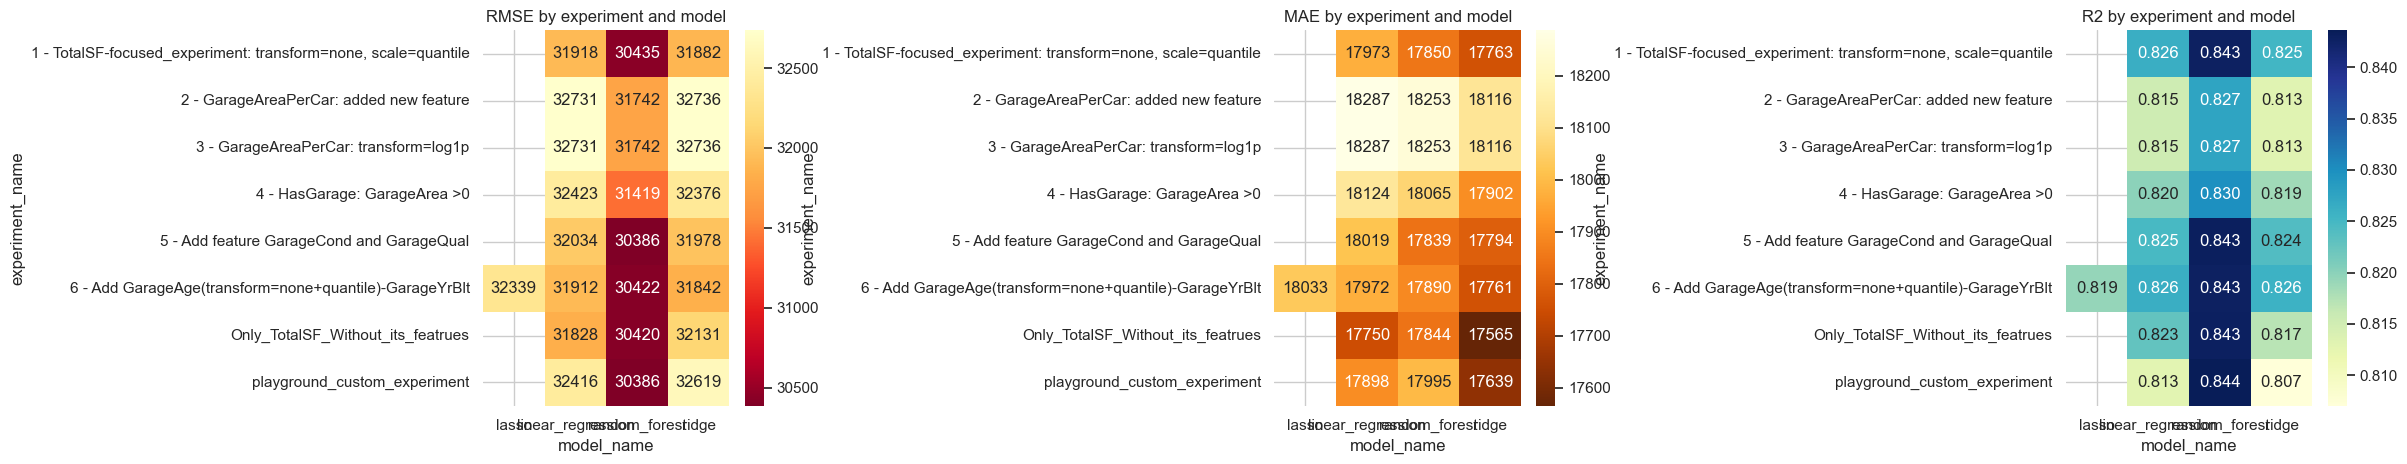

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(24, max(4, len(rmse_pivot) * 0.6)))
sns.heatmap(rmse_pivot, annot=True, fmt=".0f", cmap="YlOrRd_r", ax=axes[0])
axes[0].set_title("RMSE by experiment and model")
sns.heatmap(mae_pivot, annot=True, fmt=".0f", cmap="YlOrBr_r", ax=axes[1])
axes[1].set_title("MAE by experiment and model")
sns.heatmap(r2_pivot, annot=True, fmt=".3f", cmap="YlGnBu", ax=axes[2])
axes[2].set_title("R2 by experiment and model")
plt.tight_layout()

## Model traces across experiments

This view is helpful when you want to track one model at a time and see whether a new feature idea helped or hurt.

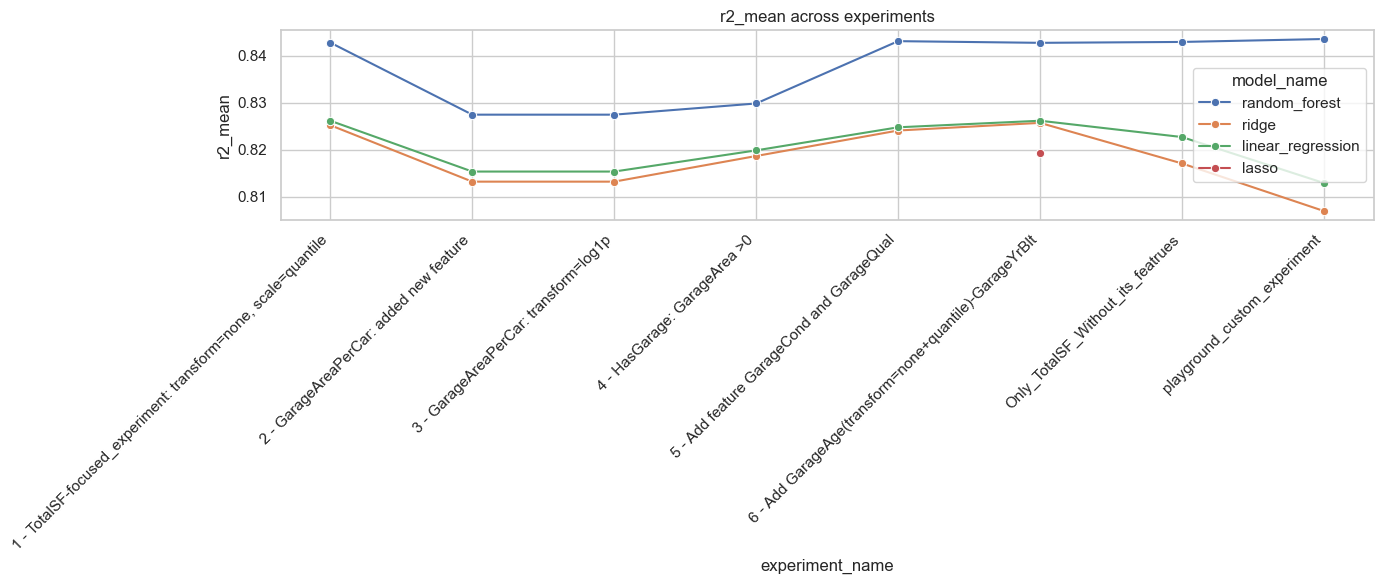

In [33]:
metric_name = "r2_mean"
plot_df = summary_df.copy()

plt.figure(figsize=(14, 6))
sns.lineplot(data=plot_df, x="experiment_name", y=metric_name, hue="model_name", marker="o")
plt.xticks(rotation=45, ha="right")
plt.title(f"{metric_name} across experiments")
plt.tight_layout()

## Drill-down: one model

Choose a model name from `available_models` and inspect only its history.

,model_name,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std,experiment_name,experiment_dir
0,random_forest,30435.378333,6143.463004,17849.810724,1611.080560,0.842819,0.077694,1 - TotalSF-focused_experiment: transform=none...,/Users/maksymponomarenko/Documents/ai-engineer...
3,random_forest,31741.906512,6908.464593,18252.878366,1392.725262,0.827497,0.092829,2 - GarageAreaPerCar: added new feature,/Users/maksymponomarenko/Documents/ai-engineer...
6,random_forest,31741.906512,6908.464593,18252.878366,1392.725262,0.827497,0.092829,3 - GarageAreaPerCar: transform=log1p,/Users/maksymponomarenko/Documents/ai-engineer...
9,random_forest,31419.110541,7130.437541,18064.900533,1604.813539,0.829876,0.096175,4 - HasGarage: GarageArea >0,/Users/maksymponomarenko/Documents/ai-engineer...
12,random_forest,30386.484817,6170.903431,17839.449358,1619.290901,0.843129,0.078313,5 - Add feature GarageCond and GarageQual,/Users/maksymponomarenko/Documents/ai-engineer...
15,random_forest,30422.442671,6211.582974,17889.571570,1650.126094,0.842771,0.078336,6 - Add GarageAge(transform=none+quantile)-Gar...,/Users/maksymponomarenko/Documents/ai-engineer...
19,random_forest,30419.765364,6147.073001,17843.892616,1612.620911,0.842961,0.077722,Only_TotalSF_Without_its_featrues,/Users/maksymponomarenko/Documents/ai-engineer...
22,random_forest,30385.801668,5862.482141,17995.026959,1518.159405,0.843584,0.074531,playground_custom_experiment,/Users/maksymponomarenko/Documents/ai-engineer...


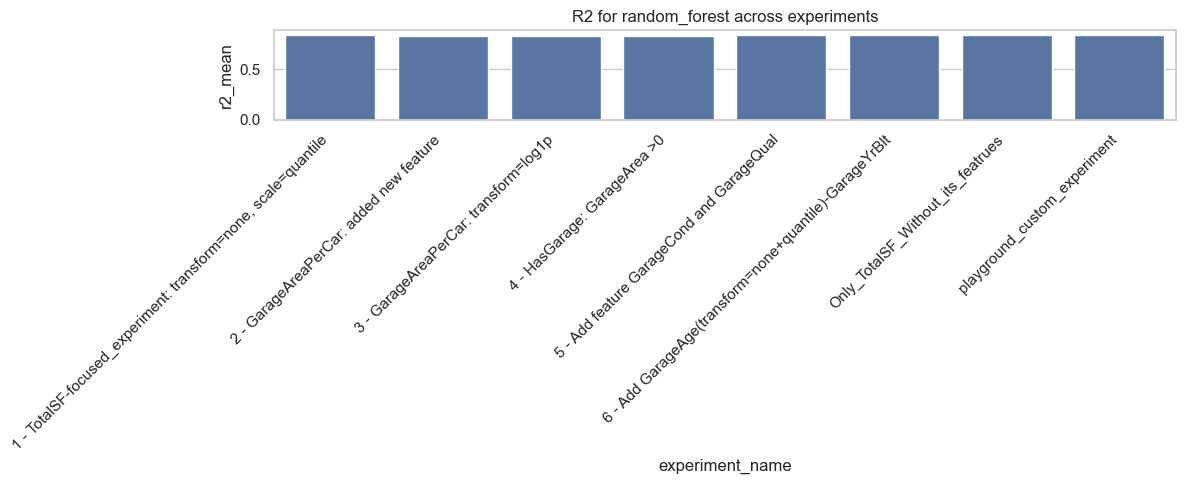

In [34]:
SELECTED_MODEL = available_models[0]
selected_model_df = summary_df.loc[summary_df["model_name"] == SELECTED_MODEL].copy()
display(selected_model_df)

plt.figure(figsize=(12, 5))
sns.barplot(data=selected_model_df, x="experiment_name", y="r2_mean")
plt.xticks(rotation=45, ha="right")
plt.title(f"R2 for {SELECTED_MODEL} across experiments")
plt.tight_layout()

## Drill-down: one experiment

Choose an experiment name and inspect every model that was saved for it.

,model_name,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std,experiment_name,experiment_dir
0,random_forest,30435.378333,6143.463004,17849.810724,1611.080560,0.842819,0.077694,1 - TotalSF-focused_experiment: transform=none...,/Users/maksymponomarenko/Documents/ai-engineer...
1,ridge,31882.313278,7121.268599,17762.631589,918.765535,0.825257,0.098052,1 - TotalSF-focused_experiment: transform=none...,/Users/maksymponomarenko/Documents/ai-engineer...
2,linear_regression,31918.499008,6739.942026,17973.103586,1029.716048,0.826206,0.090874,1 - TotalSF-focused_experiment: transform=none...,/Users/maksymponomarenko/Documents/ai-engineer...


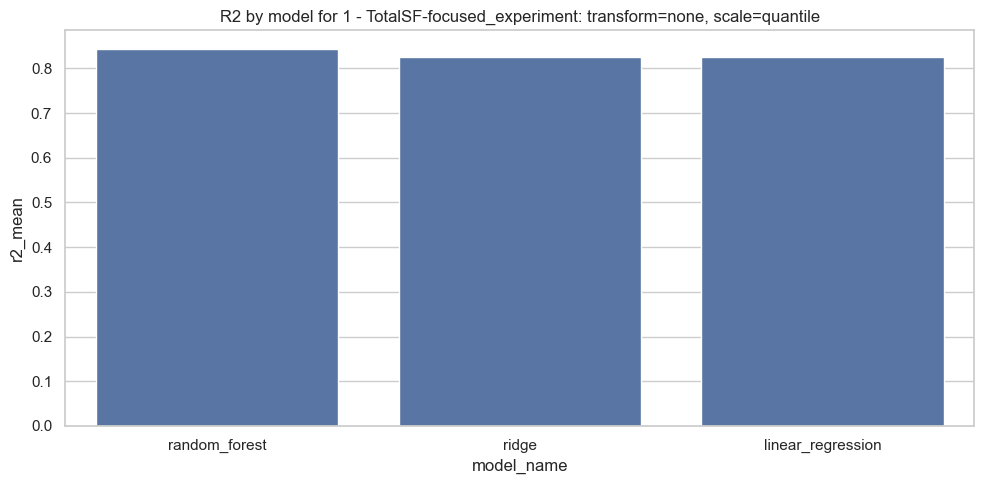

In [35]:
SELECTED_EXPERIMENT = summary_df["experiment_name"].iloc[0]
selected_experiment_df = summary_df.loc[summary_df["experiment_name"] == SELECTED_EXPERIMENT].copy()
display(selected_experiment_df.sort_values("rmse_mean"))

plt.figure(figsize=(10, 5))
sns.barplot(data=selected_experiment_df, x="model_name", y="r2_mean")
plt.title(f"R2 by model for {SELECTED_EXPERIMENT}")
plt.tight_layout()